### George Boufis (f3352504)
### Computer Assignment 1
### Numerical optimization and large scale linear algebra


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, accuracy_score 

%matplotlib inline

### Problem Setup

We start by defining the basic parameters of the problem. We have 10 lamps illuminating a 25x25 grid, which gives us 625 pixels in total. Each lamp has a position in 3D space, x and y coordinates on the floor panel and height z above the floor. We store all lamp positions in a numpy array of shape (10,3)

In [ ]:
# Define lamp positions

n = 10 # Number of lamps 
grid_size = 25 # Grid 25x25
m = grid_size * grid_size # 625 pixels 

# Lamp positions (x, y, height)
lamp_positions = [(4.1, 20.4, 4), (14.1, 21.3, 3.5), (22.6, 17.1, 6), (5.5, 12.3, 4), (12.2, 9.7, 4),
(15.3, 13.8, 6), (21.3, 10.5, 5.5), (3.9, 3.3, 5), (13.1, 4.3, 5), (20.3, 4.2, 4.5)]

lamp_positions = np.array(lamp_positions)

print(f"Number of lamps: {n}")
print(f"Number of pixels: {m}")
print(f"Lamp positions shape: {lamp_positions.shape}")


Number of lamps: 10
Number of pixels: 625
Lamp positions shape: (10, 3)


### Building the Illumination matrix A

We build the matrix A of shape (625, 10), where each element A[i,j] represents how much lamp j contributes to the illumination of pixel i. The illumination follows the inverse square law, the further a pixel is from a lamp, the less light it receives. Each pixel is assumed to be at floor level (z=0), while the lamps are at different heights above the floor. Finally, we normalize A so that when all lamps are at power 1, the average illumination across all pixels equals exactly to 1.

In [ ]:
# Computing the illumination matrix using the inverse square law 

def build_illumination_matrix(lamp_positions, grid_size):
    m = grid_size * grid_size 
    n = len(lamp_positions)
    A = np.zeros((m,n))

    # iterate over every pixel in the 25x25 grid
    pixel_idx = 0 
    for i in range(grid_size):
        for j in range(grid_size):

            #Pixel center coordinates
            pixel_x = i + 0.5
            pixel_y = j + 0.5
            pixel_z = 0.0 # floor level

            # For each lamp 
            for lamp_idx in range(n): 
                lamp_x, lamp_y, lamp_z = lamp_positions[lamp_idx]

                # Calculate 3D Euclidean distance
                distance = np.sqrt(
                    (pixel_x - lamp_x) ** 2 + 
                    (pixel_y - lamp_y) ** 2 + 
                    (pixel_z - lamp_z) ** 2  
                )

                # Inverse square law
                A[pixel_idx, lamp_idx] = 1.0 / (distance ** 2)
            pixel_idx += 1

    # Normalize A so that when all lamps have power 1, the average illumination is 1
    p_ones = np.ones(n) 
    illumination_all_ones = A @ p_ones
    avg_illumination = np.mean(illumination_all_ones)
    A = A / avg_illumination
    return A 





The output confirms that A has an expected shape (625, 10), with 625 rows for the pixels and 10 columns for the lamps. A is a tall matrix since m >> n, which means the system Ap=1 is overdetermined and we cannot solve it exaclty.

In [77]:
# Build the matrix 

A = build_illumination_matrix(lamp_positions, grid_size)
print(f"Matrix A shape: {A.shape}")


Matrix A shape: (625, 10)


### Verifying the Normalization

The output shows exactly 1 which confirms that the normalization was done correctly.

In [19]:
# Verify normalization 
p_ones = np.ones(n) 
l_ones = A @ p_ones
print(f"Average illumination with all lamps at power 1: {np.mean(l_ones):.4f}")

Average illumination with all lamps at power 1: 1.0000


### Case 1: All lamps at power 1

We set all the powers to 1 and compute the resulting illumination across all 625 pixels. We then calculate the RMS error to measure how far the actual illumination is from our desired uniform illumination of 1.
The results show that simply setting all lamps to power 1 gives a pretty uneven illumination. The range goes from 0.4018 to 1.5940, meaning some pixels receive almost 4 times more light than others. Pixels direclty below a lamp get a lot of light, while the corners of the room are much darker. 

In [20]:
# All lamps at power 1
p_all_ones = np.ones(n)
l_all_ones = A @ p_all_ones 

# Reshape to 25x25 grid for visualization 
l_grid_case1 = l_all_ones.reshape((grid_size, grid_size))

# Calculate RMS error 
l_des = np.ones(m) # Desired illumination: uniform with value 1 
error_case1 = l_all_ones - l_des 
rms_case1 = np.sqrt(np.mean(error_case1 ** 2))

print(f"Case 1 - All lamps at power 1:")
print(f"  Min illumination: {np.min(l_all_ones):.4f}")
print(f"  Max illumination: {np.max(l_all_ones):.4f}")
print(f"  Mean illumination: {np.mean(l_all_ones):.4f}")
print(f"  RMS error: {rms_case1:.4f}")

Case 1 - All lamps at power 1:
  Min illumination: 0.4018
  Max illumination: 1.5940
  Mean illumination: 1.0000
  RMS error: 0.2417


### Case 2: Least Squares via QR Decomposition

Since we cant solve Ap=1 exactly, because the system is overdetermined, we use LS to find the lamp powers that minimize the total squared error ||Ap - l_des||^2. We solve this using QR decomposition, which is a numerically stable way to solve LS. The idea is to decompose A=QR and then solve the simpler system Rp=Q^T*l_des.
The RMS error drops from 0.2417 to 0.1404, which is a significant improvement over Case 1. However, notice that some lamp powers are very different from the each other, lamp 3 gets power 2.97 while lamp 5 gets only 0.08. The optimizer is trying to compensate for the uneven lamp placement by boosting lamps in darker areas and dimming lamps in already bright areas. Also, notice that the sum of powers is 10.899 and some powers are very small but positive, there are no constraints here, so the optimizer is completely free to choose any values.

In [63]:
# Case 2: LS solution with QR decomposition

# Compute thin QR decomposition
Q, R = np.linalg.qr(A, mode='reduced')

# Solve R p = Q^T l_des
p_ls = np.linalg.solve(R, Q.T @ l_des)


# Using numpy's lstsq
print(f"\nCase 2 - Least Squares (QR Decomposition):")
print(f"  Lamp powers: {p_ls}")
print(f"  Min lamp power: {np.min(p_ls):.4f}")
print(f"  Max lamp power: {np.max(p_ls):.4f}")
print(f"  Sum of powers: {np.sum(p_ls):.4f}")

# Calculate resulting illumination
l_ls = A @ p_ls 
l_grid_case2 = l_ls.reshape((grid_size, grid_size))

# Calculate RMS error
error_case2 = l_ls - l_des 
rms_case2 = np.sqrt(np.mean(error_case2 ** 2))

print(f" RMS error: {rms_case2:.4f}")


Case 2 - Least Squares (QR Decomposition):
  Lamp powers: [1.46211018 0.78797433 2.96641047 0.74358042 0.08317333 0.21263945
 0.21218408 2.05114815 0.90760315 1.47222464]
  Min lamp power: 0.0832
  Max lamp power: 2.9664
  Sum of powers: 10.8990
 RMS error: 0.1404


### Case 2: Illumination Statistics

Comparing to Case 1, the improvement is clear. The range has narrowed from [0.4018, 1.5940] to [0.5348, 1.3373], meaning the illumination is much more uniform across the area. The mean is 0.9803, very close to our target of 1. Overall, the LS solution does a significantly better job than simply setting all lamps to power 1, reducing the RMS error by about 42%.

In [31]:
print(f"\n  Min illumination: {np.min(l_ls):.4f}")
print(f"  Max illumination: {np.max(l_ls):.4f}")
print(f"  Mean illumination: {np.mean(l_ls):.4f}")
print(f"  RMS error: {rms_case2:.4f}")



  Min illumination: 0.5348
  Max illumination: 1.3373
  Mean illumination: 0.9803
  RMS error: 0.1404


### Comparison of Case 1 and Case 2

The LS solution achieves a 41.9% reduction in RMS error compared to the naive approach of setting all lamps to power 1. This demonstrates the power of optimization, by simply redistributing the lamp powers, without changing the physical setup at all, we get a significantly more uniform illumination. 

In [32]:
print(f"\n Comparison:")
print(f"  RMS error Case 1 (all = 1): {rms_case1:.4f}")
print(f"  RMS error Case 2 (LS):      {rms_case2:.4f}")
print(f"  Improvement: {(rms_case1 - rms_case2) / rms_case1 * 100:.1f}%")


 Comparison:
  RMS error Case 1 (all = 1): 0.2417
  RMS error Case 2 (LS):      0.1404
  Improvement: 41.9%


### Case 1 & 2: Illumination colormaps

We visualize the illumination patterns of both cases side by side using a heatmap. The hot colormap goes from black (low illumination) to white (high illumination), making it easy to spot bright and dark areas. The cyan stars show the lamp positions.

Looking at the two plots, the difference is clear. In Case 1, there is a very bright spot in the center-left area where multiple lamps are clustered together, while the corners are very dark. In Case 2, the LS solution produces a much more uniform illumination, the bright spots are gone and the overall color is more consistent across the area. The corners are still slightly darker, which is expected given the physical constraints of the lamp placement, but the overall uniformity is significantly better.


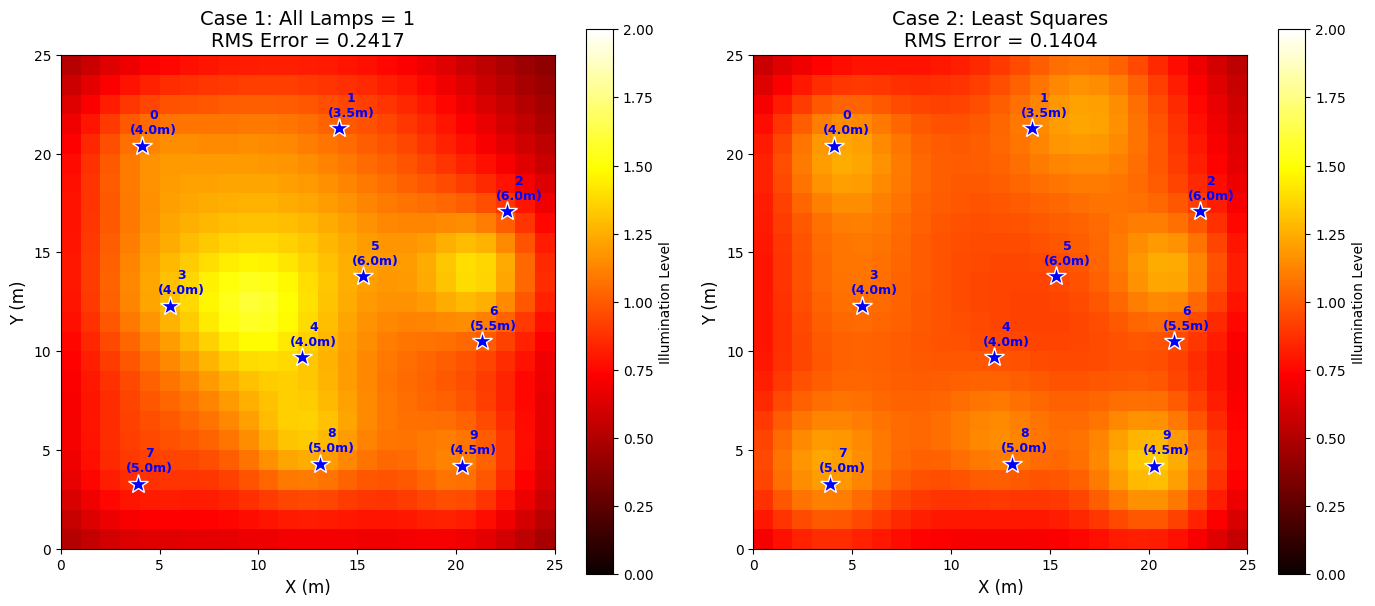

In [91]:

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Case 1: All lamps = 1
im1 = axes[0].imshow(l_grid_case1, cmap='hot', origin='lower', 
                     vmin=0, vmax=2, interpolation='nearest', extent=[0, 25, 0, 25])
axes[0].set_title(f'Case 1: All Lamps = 1\nRMS Error = {rms_case1:.4f}', fontsize=14)
axes[0].set_xlabel('X (m)', fontsize=12)
axes[0].set_ylabel('Y (m)', fontsize=12)

# Add lamp positions
for idx, (x, y, z) in enumerate(lamp_positions):
    axes[0].plot(x, y, 'b*', markersize=15, markeredgecolor='white', markeredgewidth=1)
    axes[0].text(x + 0.6, y + 0.6, f'{idx}\n({z:.1f}m)', color='blue', ha='center', fontsize=9, weight='bold')

plt.colorbar(im1, ax=axes[0], label='Illumination Level')

# Plot Case 2: Least Squares
im2 = axes[1].imshow(l_grid_case2, cmap='hot', origin='lower', 
                     vmin=0, vmax=2, interpolation='nearest', extent=[0, 25, 0, 25])
axes[1].set_title(f'Case 2: Least Squares\nRMS Error = {rms_case2:.4f}', fontsize=14)
axes[1].set_xlabel('X (m)', fontsize=12)
axes[1].set_ylabel('Y (m)', fontsize=12)

# Add lamp positions
for idx, (x, y, z) in enumerate(lamp_positions):
    axes[1].plot(x, y, 'b*', markersize=15, markeredgecolor='white', markeredgewidth=1)
    axes[1].text(x + 0.6, y + 0.6, f'{idx}\n({z:.1f}m)', color='blue', ha='center', fontsize=9, weight='bold')

plt.colorbar(im2, ax=axes[1], label='Illumination Level')

plt.tight_layout()

plt.show()



### Case 1 & 2: Histogram of Pixel Illumination

We plot the distribution of illumination values across all 625 pixels for both cases. The histogram shows how many pixels have each illumination level — a good result would be a narrow distribution centered around 1. 
In Case 1, the distribution is wide and spread out (std=0.2417, spread=1.19), meaning many pixels are far from the target of 1, some are too bright, some too dark. In Case 2, the distribution is much narrower and more concentrated around 1 (std=0.1390, spread=0.80). The least squares solution essentially squeezes the histogram closer to the target value, which is exactly what minimizing ||Ap - l_des||^2 means geometrically.

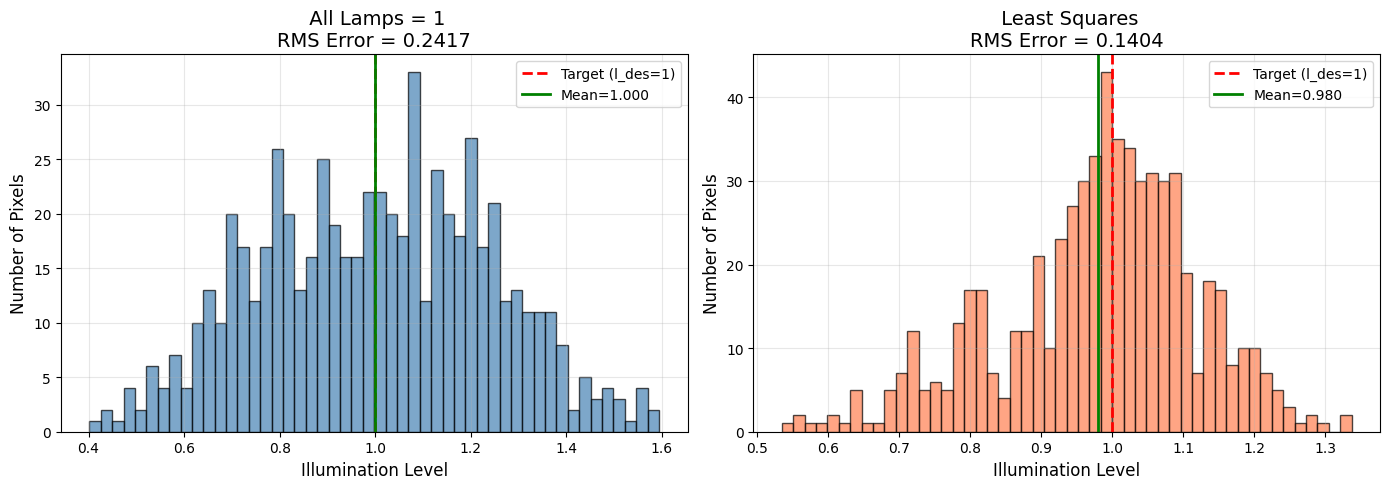


 Statistical Comparison:

 (All lamps = 1):
  Standard deviation: 0.2417
  Range: [0.4018, 1.5940]
  Spread: 1.1921

(Least Squares):
  Standard deviation: 0.1390
  Range: [0.5348, 1.3373]
  Spread: 0.8025


In [34]:
# Create Histograms 


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for Case 1
axes[0].hist(l_all_ones, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Target (l_des=1)')
axes[0].axvline(np.mean(l_all_ones), color='green', linestyle='-', linewidth=2, label=f'Mean={np.mean(l_all_ones):.3f}')
axes[0].set_xlabel('Illumination Level', fontsize=12)
axes[0].set_ylabel('Number of Pixels', fontsize=12)
axes[0].set_title(f' All Lamps = 1\nRMS Error = {rms_case1:.4f}', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram for Case 2
axes[1].hist(l_ls, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Target (l_des=1)')
axes[1].axvline(np.mean(l_ls), color='green', linestyle='-', linewidth=2, label=f'Mean={np.mean(l_ls):.3f}')
axes[1].set_xlabel('Illumination Level', fontsize=12)
axes[1].set_ylabel('Number of Pixels', fontsize=12)
axes[1].set_title(f' Least Squares\nRMS Error = {rms_case2:.4f}', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# Additional statistics
print("\n Statistical Comparison:")
print(f"\n (All lamps = 1):")
print(f"  Standard deviation: {np.std(l_all_ones):.4f}")
print(f"  Range: [{np.min(l_all_ones):.4f}, {np.max(l_all_ones):.4f}]")
print(f"  Spread: {np.max(l_all_ones) - np.min(l_all_ones):.4f}")

print(f"\n(Least Squares):")
print(f"  Standard deviation: {np.std(l_ls):.4f}")
print(f"  Range: [{np.min(l_ls):.4f}, {np.max(l_ls):.4f}]")
print(f"  Spread: {np.max(l_ls) - np.min(l_ls):.4f}")

### PART 3)

### Constraing LS

Lamp powers cannot be negative and there is always an energy budget. We add two constraints to our optimization problem: the total power must equal 10 and no lamp can have negative power. We use SLSQP (Sequential Least Squares Programming) from scipy, which handles both equality constraints and bounds efficiently. We also provide the analytical gradient of the objective function to speed up the optimization.
The sum of powers is exactly 10.00 and the minimum power is 0.00, confirming that both constraints are satisfied. Notice that lamp 6 was completely switched off, the optimizer decided it was better to redistribute its power to other lamps. This makes sense given its central position where the area is already well lit by neighboring lamps. Compared to the unconstrained LS (RMS=0.1404), the constraints force a slightly worse solution, which is always expected when we add restrictions to an optimization problem.

In [ ]:
# Part 3 : Constrained Optimization 
from scipy.optimize import minimize

# Define the objective function : min||Ap - l_des||^2
def objective(p):
    residual = A @ p - l_des 
    return np.sum(residual ** 2)

 # Analytical gradient: 2 * A^T (Ap - l_des)
def objective_grad(p):
    residual = A @ p - l_des 
    return 2 * (A.T @ residual)


# Initial guess
p0 = np.ones(n) 

# Constraints
constraints = [
    {'type' : 'eq', 'fun' : lambda p : np.sum(p) - 10} # Sum of powers = 10
]

# Bounds: p_i >= 0 for all i
bounds = [(0, None)] * n 

# Solve using SLSQP
result = minimize(objective, p0, method = 'SLSQP',jac = objective_grad,  bounds = bounds, constraints = constraints
)



p_constrained = result.x 

print(f"\nCase 3 - Constrained Least Squares:")
print(f"  Lamp powers: {p_constrained}")
print(f"  Min lamp power: {np.min(p_constrained):.4f}")
print(f"  Max lamp power: {np.max(p_constrained):.4f}")
print(f"  Sum of powers: {np.sum(p_constrained):.4f} ")




Case 3 - Constrained Least Squares:
  Lamp powers: [1.33952562 0.89427816 2.36807757 0.77919849 0.31889442 0.
 0.39505695 1.76363844 0.76041964 1.38091071]
  Min lamp power: 0.0000
  Max lamp power: 2.3681
  Sum of powers: 10.0000 


### Case 3: Constrained Illumination Statistics
We compute the illumination achieved by the constrained solution and measure its RMS error.
The constrained solution is slightly worse than the unconstrained LS (0.1558 vs 0.1404), which is expected, adding constraints always limits the optimizer's freedom. However it is still much better than the naive Case 1.

In [36]:
# Calculate resulting illumination
l_constrained = A @ p_constrained
l_grid_case3 = l_constrained.reshape((grid_size, grid_size))

# Calculate RMS error
error_case3 = l_constrained - l_des 
rms_case3 = np.sqrt(np.mean(error_case3 ** 2))


print(f"\n  Min illumination: {np.min(l_constrained):.4f}")
print(f"  Max illumination: {np.max(l_constrained):.4f}")
print(f"  Mean illumination: {np.mean(l_constrained):.4f}")
print(f"  RMS error: {rms_case3:.4f}")


  Min illumination: 0.4719
  Max illumination: 1.2563
  Mean illumination: 0.9245
  RMS error: 0.1558


### Summary of Cases 1,2 and 3

The results follow a clear pattern that reflects a fundamental principle of optimization: the more constraints you add, the worse the objective function gets. The unconstrained LS (Case 2) gives the best possible RMS for this lamp configuration, while adding the energy budget and non-negativity constraints (Case 3) slightly increases the RMS. 

In [37]:
print(f"\n Final Comparison:")
print(f"  RMS error Case 1 (all = 1):        {rms_case1:.4f}")
print(f"  RMS error Case 2 (LS):             {rms_case2:.4f}")
print(f"  RMS error Case 3 (Constrained LS): {rms_case3:.4f}")


 Final Comparison:
  RMS error Case 1 (all = 1):        0.2417
  RMS error Case 2 (LS):             0.1404
  RMS error Case 3 (Constrained LS): 0.1558


### Case 3: Constrained LS Colormap

We visualize the illumination pattern of the constrained solution.
The illumination is more uniform than Case 1 but we can still see some uneven areas, particularly the top-left and bottom-right corners appear brighter while the edges of the area are darker. This is a direct consequence of the constraints: with a fixed energy budget of 10 and no negative powers, the optimizer cannot fully compensate for the uneven lamp placement. The lamp that was switched off (lamp 6) leaves a visible gap in coverage compared to the unconstrained solution.

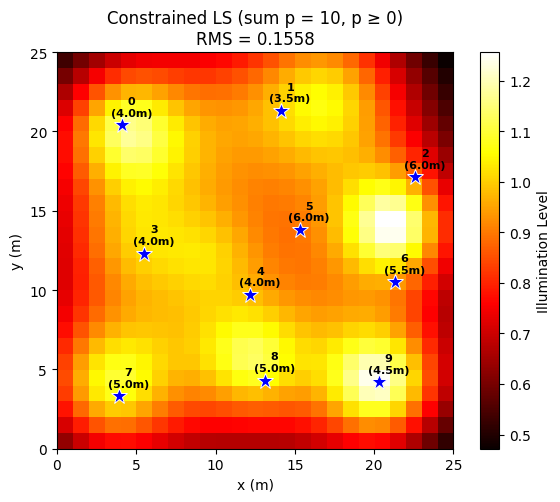

In [96]:
# Colormap of constrained Solution

l_grid_case3 = l_constrained.reshape(grid_size, grid_size)

plt.figure(figsize=(6,5))

im = plt.imshow(
    l_grid_case3,
    cmap='hot',
    origin='lower',
    extent=[0, 25, 0, 25]
)


# Plot lamp positions with index and height
for idx, (x, y, z) in enumerate(lamp_positions):
    plt.plot(x, y, 'b*', markersize=12, markeredgecolor='white', markeredgewidth=0.7)
    plt.text(x + 0.6, y + 0.6, f'{idx}\n({z:.1f}m)', color='black',
             ha='center', fontsize=8, weight='bold')
             




plt.title(f'Constrained LS (sum p = 10, p ≥ 0)\nRMS = {rms_case3:.4f}')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.colorbar(im, label='Illumination Level')

plt.tight_layout()
plt.show()

### Case 3: Constrained LS Histogram
We plot the distribution of illumination values for the constrained solution.
The histogram shows a distribution centered around 0.924, which is slightly below our target of 1. The distribution is wider than the unconstrained LS case and has a visible tail on the left side, meaning some pixels are significantly under-illuminated. This is a direct consequence of switching off lamp 6, the areas it used to cover now receive less light. Overall though, the distribution is still much better than Case 1, with most pixels concentrated in the 0.9-1.1 range.

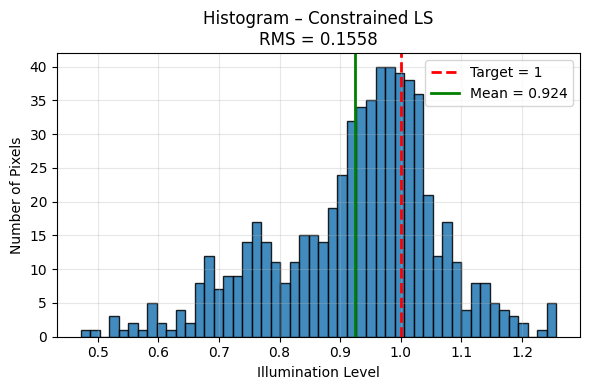

In [39]:
# Histogram of constrained solution
plt.figure(figsize=(6,4))

plt.hist(l_constrained, bins=50, edgecolor='black', alpha=0.85)
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Target = 1')
plt.axvline(np.mean(l_constrained), color='green', linewidth=2,
            label=f'Mean = {np.mean(l_constrained):.3f}')

plt.title(f'Histogram – Constrained LS\nRMS = {rms_case3:.4f}')
plt.xlabel('Illumination Level')
plt.ylabel('Number of Pixels')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Case 4: Random Search for Optimal Lamp Positions
In all previous cases we kept the lamp positions fixed and only optimized the powers. Here we go one step further, we also optimize the lamp positions by randomly sampling 1000 different configurations and for each one we solve the constrained LS problem. The best configuration found across all iterations is kept as the final solution.
The search found two improvements, at iteration 28 (RMS=0.1138) and iteration 47 (RMS=0.0963)  and then no further improvement was found in the remaining 953 iterations. The final RMS of 0.0963 is a 31.38% improvement over Case 2, which shows that lamp placement is just as important as power optimization. Notice that the best positions tend to be spread towards the edges and corners of the area, which makes physical sense, placing lamps near the boundaries helps illuminate the darker corner regions that are hardest to reach.

In [ ]:
# Part 4

rng = np.random.default_rng(42)

# Target RMS to beat 
target_rms = rms_case2 
best_rms = target_rms

best_positions = None
best_powers = None
best_illumination = None

rms_history = []

# Iterative search for better lamp positions
for it in range(1000):
    # Generate random 3D coordinates within allowed boundaries
    random_positions = np.empty((n, 3))
    random_positions[:, 0] = rng.uniform(0, 25, size=n)  # x
    random_positions[:, 1] = rng.uniform(0, 25, size=n)  # y
    random_positions[:, 2] = rng.uniform(4, 6, size=n)   # h
    
    # Build the sensitivity matrix A for the new geometry
    A_new = build_illumination_matrix(random_positions, grid_size)

    res = minimize(
        lambda p: np.sum((A_new @ p - l_des) ** 2),
        p0,
        method = 'SLSQP',
        bounds = bounds,
        constraints = constraints,
        options={"maxiter": 200, "ftol":1e-10}
    )

    if not res.success:
        continue

    p_new = res.x 
    l_new = A_new @ p_new
    rms_new = np.sqrt(np.mean((l_new - l_des) ** 2))
    rms_history.append(rms_new)

    if rms_new < best_rms:
        best_rms = rms_new
        best_positions = random_positions.copy()
        best_powers = p_new.copy()
        best_illumination = l_new.copy()
        print(f"Iter {it+1}: best RMS={best_rms:.4f} | {best_rms < target_rms}")


print(f"\n{'='*70}")

print(f"{'='*70}")
print(f"Original RMS (Case 2): {target_rms:.4f}")
print(f"Best RMS found:        {best_rms:.4f}")
print(f"Improvement:           {(target_rms - best_rms)/target_rms*100:.2f}%")
print(f"\nBest lamp positions found:")
for i, pos in enumerate(best_positions):
    print(f"  Lamp {i}: ({pos[0]:.2f}, {pos[1]:.2f}, {pos[2]:.2f})")
print(f"\nBest lamp powers:")
for i, power in enumerate(best_powers):
    print(f"  Lamp {i}: {power:.4f}")
print(f"Sum of powers: {np.sum(best_powers):.4f}")







Iter 28: best RMS=0.1138 | True
Iter 47: best RMS=0.0963 | True

Original RMS (Case 2): 0.1404
Best RMS found:        0.0963
Improvement:           31.38%

Best lamp positions found:
  Lamp 0: (10.78, 23.40, 4.89)
  Lamp 1: (0.90, 20.94, 4.13)
  Lamp 2: (13.37, 2.94, 5.94)
  Lamp 3: (24.84, 1.50, 4.62)
  Lamp 4: (23.97, 20.87, 4.38)
  Lamp 5: (1.01, 3.89, 4.57)
  Lamp 6: (17.64, 13.37, 5.93)
  Lamp 7: (7.54, 22.89, 4.19)
  Lamp 8: (22.57, 14.19, 5.73)
  Lamp 9: (1.13, 9.93, 5.42)

Best lamp powers:
  Lamp 0: 1.2373
  Lamp 1: 0.9210
  Lamp 2: 1.7828
  Lamp 3: 1.2032
  Lamp 4: 1.0073
  Lamp 5: 0.8843
  Lamp 6: 1.1436
  Lamp 7: 0.1021
  Lamp 8: 0.5277
  Lamp 9: 1.1907
Sum of powers: 10.0000


### Case 4: Colormap of Best Configuration 
We visualize the illumination pattern of the best lamp configuration found by the random search. Each lamp is labeled with its index and height above the floor.
The colormap clearly shows why this configuration achieves a much better RMS of 0.0963. Compared to the original lamp placement, the lamps are now spread much more evenly across the area, most of them are positioned near the edges and corners (lamps 2, 4, 5, 6, 8, 10) rather than clustered in the center. This ensures that every part of the room receives adequate illumination. There are still some darker areas visible, particularly in the bottom-center and right-center regions, but overall the illumination is significantly more uniform than any of the previous cases.

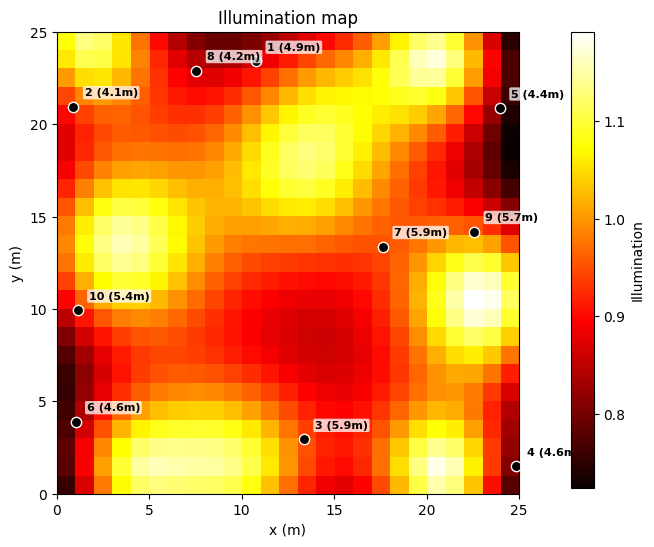

In [82]:
# reshape best illumination to 25x25 grid
img = best_illumination.reshape(grid_size, grid_size)  

fig, ax = plt.subplots(figsize=(7.5, 6))

im = ax.imshow(
    img,
    origin="lower",
    extent=[0, 25, 0, 25],
    cmap="hot"
)


positions = best_positions  

# plot each lamp with its index and height label
for idx, (x, y, h) in enumerate(positions):
    ax.scatter(
        x, y,
        c="black",
        s=55,
        edgecolors="white",
        linewidths=1.0,
        zorder=3
    )
    ax.text(
        x + 0.6, y + 0.6,
        f"{idx+1} ({h:.1f}m)",
        fontsize=8,
        weight="bold",
        color="black",
        bbox=dict(boxstyle="round",pad=0.15, facecolor="white", edgecolor="none", alpha=0.75),
        zorder=4
    )

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Illumination map")

ax.set_xlim(0, 25)
ax.set_ylim(0, 25)

# --- Create extra space on the right BEFORE adding colorbar ---
# right=0.82 leaves a bigger gap for the colorbar
fig.subplots_adjust(right=0.82)


cax = fig.add_axes([0.85, 0.12, 0.03, 0.76])  # [left, bottom, width, height]
cb = fig.colorbar(im, cax=cax)
cb.set_label("Illumination")

plt.show()

### Case 4: Histogram of Best Configuration
A final look at the distribution of illumination values for the best configuration found by the random search.
This is the best result we achieved across all four cases. The histogram is tightly concentrated in the range [0.75, 1.2], with the mean at 0.981, very close to the target of 1.

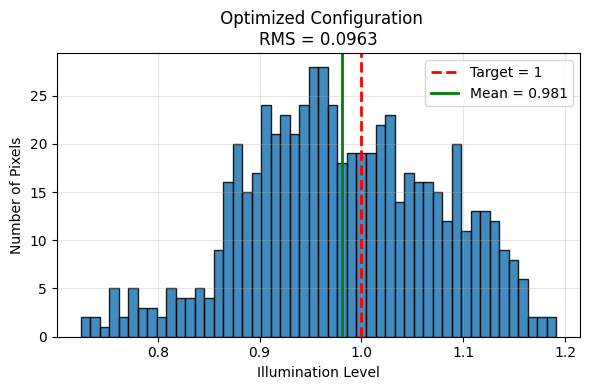

In [ ]:
# safety check in case the optimization found no improvement
if best_illumination is None:
    raise ValueError("No best solution found. Run the Q4 optimization first.")

plt.figure(figsize=(6,4))

# histogram of pixel illumination values
plt.hist(best_illumination, bins=50, edgecolor='black', alpha=0.85)

# reference lines for target and mean
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Target = 1')

# Mean line
mean_val = np.mean(best_illumination)
plt.axvline(mean_val, color='green', linewidth=2,
            label=f'Mean = {mean_val:.3f}')

plt.title(f' Optimized Configuration\nRMS = {best_rms:.4f}')
plt.xlabel('Illumination Level')
plt.ylabel('Number of Pixels')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Compare the results from all the Cases 1,2,3 and 4

| Case | RMS | Mean |
|------|-----|------|
| All lamps = 1 | 0.2417 | 1.000 |
| Unconstrained LS | 0.1404 | 0.980 |
| Constrained LS | 0.1558 | 0.924 |
| Random Search | 0.0963 | 0.981 |

We had to not only optimizing the powers but also we had to optimize the lamp positions. That lead to significantly better results. By spreading the lamps towards the edges and corners of the area, the random search found a configuration that is inherently more uniform, making the power optimization problem much easier to solve.

### Case 4: Random Search Progress
We plot the RMS error of each iteration to visualize how the random search behaved across all 1000 attempts.
The plot shows that the vast majority of random configurations produce an RMS well above the target line (0.1404). The search space is very large and most random lamp placements give poor results, the RMS fluctuates between 0.15 and almost 0.45 for most iterations. Only a handful of configurations managed to dip below the target line, and the best one (RMS=0.0963) was found at iteration 47. 

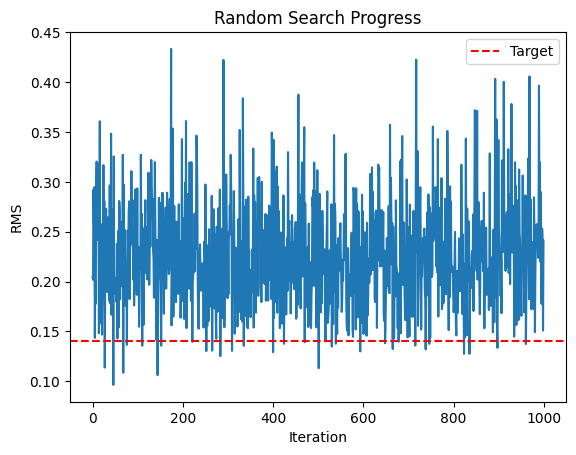

In [79]:
plt.plot(rms_history)
plt.axhline(target_rms, color='red', linestyle='--', label='Target')
plt.xlabel('Iteration')
plt.ylabel('RMS')
plt.title('Random Search Progress')
plt.legend()
plt.show()